Setting static fields is actually possible for zodiax classes - however this is somewhat unsafe as it opens the possibility of users entering non-static field to update and breaking the pytree structure. 

It may instead be possible to wrap this behaviour into an catch branch somewhere in the .set() method of the class.

This would overall allow for string values to be set to the class, while still having them recognised as pure-jax pytrees.

Note: The error that needs to be caught is an empty assertion error, which is generic and dangerous to catch. It could be possible to talk with Patrick about putting in a specific error message, so that it can be directly checked against, ensuring that we are not catching any other errors.

This needs to also have its jit and gradability checked

In [1]:
import zodiax as zdx

class Foo(zdx.Base):
    value : str = zdx.field(static=True)
    
    def __init__(self):
        self.value = 'foo'

In [2]:
class FooReturned(Foo):
    def set_static(self, key, value):
        object.__setattr__(self, key, value)
        return self

foo = FooReturned()

# This prints the updated object, like we expect an immutable class to work
print(foo.set_static('value', 'bar'))

# This prints the updated object too, even though we never re-assigned the variable foo :(
print(foo)

FooReturned(value='bar')
FooReturned(value='bar')


In [3]:
class FooNotReturned(Foo):
    def set_static(self, key, value):
        object.__setattr__(self, key, value)

foo = FooNotReturned()
print(foo.set_static('value', 'bar'))

foo = foo.set_static('value', 'bar')
print(foo)

None
None


In [4]:
from functools import partial
import jax

class FooException(Foo):
    test : float = 1.

    @partial(jax.jit, static_argnums=(1, 2,))
    def set_static(self, key, value):
        object.__setattr__(self, key, value)
        return self

    def set(self, key, value):
        try:
            return super().set(key, value)
        except AssertionError:
            try:
                return self.set_static(key, value)
            except ValueError:
                raise ValueError(f"Static leaves can only be set to hashable data types. Tried to set the leaf '{key}' with a {type(value)} type.")
        return self

foo = FooException()
print(foo.set('test', 2.))

foo = FooException()
print(foo.set('test', 2.).test)

print(foo.set('value', 'bar'))
print(foo)

foo = foo.set('value', 'bar')
print(foo)

FooException(value='foo', test=f32[])
2.0
FooException(value='bar', test=1.0)
FooException(value='foo', test=1.0)
FooException(value='bar', test=1.0)


In [5]:
foo = FooException()
print(foo.set('value', jax.numpy.ones(2)))


ValueError: Static leaves can only be set to hashable data types. Tried to set the leaf 'value' with a <class 'jaxlib.xla_extension.ArrayImpl'> type.

In [6]:
import jax

@jax.jit
def update_foo(foo_cls):
    foo_cls.set('value', 'baz')
    return foo_cls

foo = FooException()
new_foo = update_foo(foo)
print(foo)
print(new_foo)

FooException(value='foo', test=1.0)
FooException(value='foo', test=1.0)


In [7]:
foo = FooException()
new_foo = update_foo(foo)
print(foo)
print(new_foo)

FooException(value='foo', test=1.0)
FooException(value='foo', test=1.0)


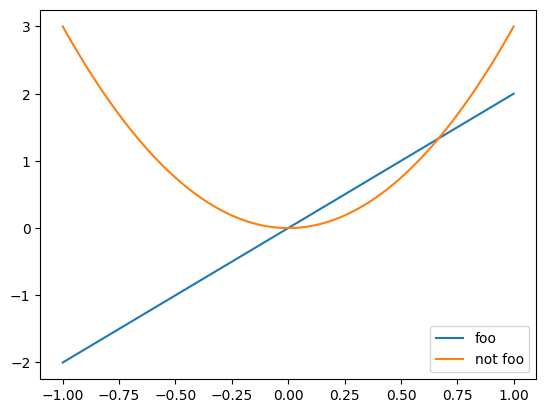

In [8]:
import jax.numpy as np
import matplotlib.pyplot as plt

@jax.jit
@jax.grad
def test_fn(x, foo_cls):
    if foo_cls.value == 'foo':
        return x**2
    else:
        return x**3

test_fn_vmap = jax.vmap(test_fn, in_axes=(0, None))

foo = FooException()
xs = np.linspace(-1, 1, 100)

plt.plot(xs, test_fn_vmap(xs, foo), label='foo')
plt.plot(xs, test_fn_vmap(xs, foo.set('value', 2)), label='not foo')
plt.legend()
plt.savefig("output.png")

In [9]:
import equinox as eqx

class Foo(eqx.Module):
    bar : str = eqx.field(static=True)

    def __init__(self):
        self.bar = 'baz'

eqx.tree_at(lambda tree: tree.bar, Foo(), 'new_baz')

AssertionError: 

In [8]:

try:
    eqx.tree_at(lambda tree: tree.bar, 'new_baz')
except AttributeError as e:
    print(e)

'str' object has no attribute 'bar'


AssertionError: 